# 26-YZM212 ML
## MLE - Akıllı Şehir Trafik Modelleme

### Bağımlılıklar

In [28]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Bölüm 2

### Trafik Verisi

In [29]:
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

### Negative Log Likelihood Fonksiyonu

In [30]:
# minimize etmek icin objektifimiz - Negative Log Likelihood
# "where ``x`` is a 1-D array with shape (n,)" yazmislar dokumantasyona o yuzden lam liste geliyor
def neg_lnlikelihood(lam, data):
    lam = lam[0]
    neglogl = -(np.sum(data * np.log(lam) - lam)) # x_i * ln(lambda) - lambda * ln(e) + ... -> log likelihood sadelestikten sonra bu cikiyor kalan kismi lambdaya bagli degil minimize edecek bir seyi yok

    return neglogl

### Optimizasyon ile Lambda Tahmini

In [31]:
initial_guess = [1.0]

result = opt.minimize(
    neg_lnlikelihood, # objektif
    initial_guess, # ilk parametre
    args=(traffic_data,), # objektifin 2. parametresi datalar
)

print("Numerik lambda:", result.x[0])
print("Analitik:", np.mean(traffic_data))

Numerical MLE lambda: 12.142859681866254
Analytical (Mean): 12.142857142857142


## Bölüm 3 - Poisson Modeli ve Histogram

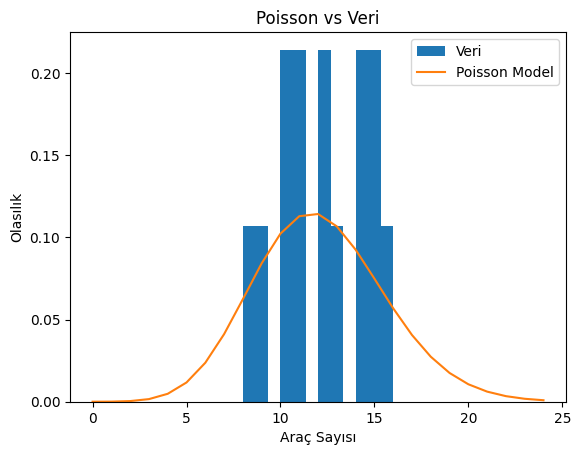

In [32]:
lam = result.x[0]

x = np.arange(0, 25) # [0,...,24] array olusturduk 25 farazi (5, 20)-len=15 pek iyi durmuyo

pmf = poisson.pmf(x, lam)

plt.hist(traffic_data, bins=traffic_data.size-2, density=True, alpha=1, label="Veri") #Veri labeli ile gorulen kutucuklari ekler
plt.plot(x, pmf, label="Poisson Model")

plt.xlabel("Araç Sayısı")
plt.ylabel("Olasılık")
plt.title("Poisson vs Veri")
plt.legend()
plt.show()

# Yorumlama

#### Veri her ne kadar %100 oturmasa bile event temsilinde başarılı duruyor nümerik ve analitik çözümler de zaten birbirine çok yakın bu modelle sampling yapsak benzer bir dağılımı bize gösterebilir bu yüzden model veriye uyuyor ya da veri modeli iyi temsil ediyor denebilir.

## Bölüm 4 - Outlier Analizi

In [33]:
outlier = np.append(traffic_data, 200)

print("Normal Ortalama:", np.mean(traffic_data))
print("Outlier Etkili Ortalama:", np.mean(outlier))

Normal Ortalama: 12.142857142857142
Outlier Etkili Ortalama: 24.666666666666668
